# Apply LSTM model to hydro data

Use HydroDF csv that was downloaded and compiled in [LSTM_data](LSTM_data.ipynb). Use torch310 environment.

In [1]:
import os
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import joblib

from supportingscripts import LSTM_helper

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In this application, the LSTM uses a 30-day lookback window of meteorological and hydrologic inputs to predict daily streamflow. By learning relationships across time, the model can represent processes such as snowmelt timing, precipitation-runoff response, and seasonal dynamics, making it well-suited for hydrologic forecasting tasks.


Data splitting:
- Training: Diamond Fork near Thistle (10149400), Weber River near Oakley (10128500), and American Fork near American Fork (10164500)
- Validation: East Canyon Creek near Jeremy Ranch (10133800)
- Testing: McLeod Creek near Park City (10133600)

In [74]:
# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Data parameters
FILE_PATH = "data/HydroDF/HydroDF.csv"
SITE_COL = "site_no"
DATE_COL = "Date"
TARGET_COL = "flow_cfs"

# Hyperparameters
LOOKBACK_DAYS = 90 #number of past time steps to use for prediction
BATCH_SIZE = 64 #number of samples per batch for training
EPOCHS = 50 #number of times to iterate over the entire training dataset
PATIENCE = 10 #number of epochs to wait for improvement in validation loss before stopping training
LEARNING_RATE = 1e-3 #step size for updating model parameters during training

# Define the SITES for splitting the dataset into training, validation, and testing sets
TRAIN_SITES = (10149400, 10128500, 10164500)
VAL_SITE = 10133800
TEST_SITE = 10133600


### Load and inspect data

In [75]:
# Load and preprocess the data
df = pd.read_csv(FILE_PATH, index_col=False)

# Clean column names, removing spaces and special characters
clean_cols = []
for c in df.columns:
    c = str(c).strip().replace('"', '')
    c = ''.join(ch if ch.isalnum() else '_' for ch in c)
    while '__' in c:
        c = c.replace('__', '_')
    c = c.strip('_')
    clean_cols.append(c)
df.columns = clean_cols

# Convert date column to datetime and sort by date
df[DATE_COL] = pd.to_datetime(df[DATE_COL])
df = df.sort_values(DATE_COL).reset_index(drop=True)

print('Rows:', len(df))
print('Date range:', df[DATE_COL].min().date(), 'to', df[DATE_COL].max().date())
print('Sites:', sorted(df[SITE_COL].unique()))
df.head()

Rows: 49218
Date range: 1980-01-01 to 2019-12-31
Sites: [np.int64(0), np.int64(10128500), np.int64(10133600), np.int64(10133800), np.int64(10149400), np.int64(10164500)]


,Date,site_no,flow_cfs,SWE_cm,dayl_s,prcp_mm_day,srad_W_m2,swe_cm,tmax_C,tmin_C,...,longwave_radiation,potential_energy,potential_evaporation,pressure,shortwave_radiation,specific_humidity,temperature,total_precipitation,wind_u,wind_v
0,1980-01-01,10128500,39.0,8.128,32891.95,0.00,150.63,6.609,0.26,-5.67,...,257.265065,11.840436,0.026938,72148.903993,80.995231,0.003423,-4.145117,0.195818,3.444077,-0.780383
1,1980-01-01,10164500,16.0,15.494,33000.78,4.50,92.79,3.985,1.03,-3.26,...,278.689838,5.994014,0.008046,77096.498145,59.288830,0.003436,-2.607362,0.266971,0.787105,-0.097493
2,1980-01-02,10128500,40.0,8.128,32934.47,0.00,243.20,6.609,-0.95,-11.14,...,177.230928,18.452944,0.015581,72136.435738,103.197019,0.002453,-8.782047,0.031073,2.809815,-1.998625
3,1980-01-02,10164500,16.0,15.494,33042.81,4.22,152.35,4.407,0.39,-7.08,...,264.265524,27.747052,0.010779,77208.987125,80.444898,0.003367,-3.740573,0.063661,1.168021,-0.238665
4,1980-01-03,10128500,43.0,8.128,32980.46,6.45,232.51,7.254,0.03,-16.01,...,210.763688,0.000000,0.042098,72132.334681,86.063714,0.001956,-8.037497,0.000000,4.134117,1.045930


### Choose predictors

In [76]:
# Identify numeric feature columns, excluding target and date columns
exclude_cols = {TARGET_COL, SITE_COL, 'Date', 'station_id', 'Unnamed_0'}

# We want to include only numeric columns as features, and exclude any non-numeric or irrelevant columns
numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
feature_cols = [c for c in numeric_cols if c not in exclude_cols]

print('Target column:', TARGET_COL)
print('Number of features:', len(feature_cols))
print(feature_cols)

Target column: flow_cfs
Number of features: 20
['SWE_cm', 'dayl_s', 'prcp_mm_day', 'srad_W_m2', 'swe_cm', 'tmax_C', 'tmin_C', 'vp_Pa', 'tmean', 'convective_fraction', 'longwave_radiation', 'potential_energy', 'potential_evaporation', 'pressure', 'shortwave_radiation', 'specific_humidity', 'temperature', 'total_precipitation', 'wind_u', 'wind_v']


### Choose feature columns

If necessary, may not need to reduce the number of features the model looks at.

In [77]:
# choose features
#feature_cols = ['SWE_cm', 'prcp_mm_day', 'shortwave_radiation', 'tmax_C', 'tmin_C', 'potential_evaporation', 'total_precipitation']
cols = feature_cols + [TARGET_COL]

# keep the date column for tracking predictions by date
# select site, date, and model columns from the dataframe
df = df[[SITE_COL, DATE_COL] + cols]
df.head()

,site_no,Date,SWE_cm,dayl_s,prcp_mm_day,srad_W_m2,swe_cm,tmax_C,tmin_C,vp_Pa,...,potential_energy,potential_evaporation,pressure,shortwave_radiation,specific_humidity,temperature,total_precipitation,wind_u,wind_v,flow_cfs
0,10128500,1980-01-01,8.128,32891.95,0.00,150.63,6.609,0.26,-5.67,400.20,...,11.840436,0.026938,72148.903993,80.995231,0.003423,-4.145117,0.195818,3.444077,-0.780383,39.0
1,10164500,1980-01-01,15.494,33000.78,4.50,92.79,3.985,1.03,-3.26,480.17,...,5.994014,0.008046,77096.498145,59.288830,0.003436,-2.607362,0.266971,0.787105,-0.097493,16.0
2,10128500,1980-01-02,8.128,32934.47,0.00,243.20,6.609,-0.95,-11.14,261.14,...,18.452944,0.015581,72136.435738,103.197019,0.002453,-8.782047,0.031073,2.809815,-1.998625,40.0
3,10164500,1980-01-02,15.494,33042.81,4.22,152.35,4.407,0.39,-7.08,359.27,...,27.747052,0.010779,77208.987125,80.444898,0.003367,-3.740573,0.063661,1.168021,-0.238665,16.0
4,10128500,1980-01-03,8.128,32980.46,6.45,232.51,7.254,0.03,-16.01,175.37,...,0.000000,0.042098,72132.334681,86.063714,0.001956,-8.037497,0.000000,4.134117,1.045930,43.0


### Fill missing values

In [78]:
# Check for missing values, fill them using linear interpolation, forward fill, and backward fill
df[feature_cols + [TARGET_COL]] = (
    df[feature_cols + [TARGET_COL]]
    .interpolate(method='linear', limit_direction='both')
    .ffill()
    .bfill()
)

### Data split

Split data by site into training, validation, and testing data sets

In [79]:
# Split the data into training, validation, and testing sets based on site numbers

train_df = df[df[SITE_COL].isin(TRAIN_SITES)].copy()
val_df = df[df[SITE_COL] == VAL_SITE].copy()
test_df = df[df[SITE_COL] == TEST_SITE].copy()

print('Train rows:', len(train_df))
print('Validation rows:', len(val_df))
print('Test rows:', len(test_df))

Train rows: 29798
Validation rows: 6666
Test rows: 8463


In [80]:
train_df.head()

,site_no,Date,SWE_cm,dayl_s,prcp_mm_day,srad_W_m2,swe_cm,tmax_C,tmin_C,vp_Pa,...,potential_energy,potential_evaporation,pressure,shortwave_radiation,specific_humidity,temperature,total_precipitation,wind_u,wind_v,flow_cfs
0,10128500,1980-01-01,8.128,32891.95,0.00,150.63,6.609,0.26,-5.67,400.20,...,11.840436,0.026938,72148.903993,80.995231,0.003423,-4.145117,0.195818,3.444077,-0.780383,39.0
1,10164500,1980-01-01,15.494,33000.78,4.50,92.79,3.985,1.03,-3.26,480.17,...,5.994014,0.008046,77096.498145,59.288830,0.003436,-2.607362,0.266971,0.787105,-0.097493,16.0
2,10128500,1980-01-02,8.128,32934.47,0.00,243.20,6.609,-0.95,-11.14,261.14,...,18.452944,0.015581,72136.435738,103.197019,0.002453,-8.782047,0.031073,2.809815,-1.998625,40.0
3,10164500,1980-01-02,15.494,33042.81,4.22,152.35,4.407,0.39,-7.08,359.27,...,27.747052,0.010779,77208.987125,80.444898,0.003367,-3.740573,0.063661,1.168021,-0.238665,16.0
4,10128500,1980-01-03,8.128,32980.46,6.45,232.51,7.254,0.03,-16.01,175.37,...,0.000000,0.042098,72132.334681,86.063714,0.001956,-8.037497,0.000000,4.134117,1.045930,43.0


### Fit scalars on training data

In [81]:
# Scale features and target using MinMaxScaler, fit on training data only to prevent data leakage
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

# Fit the scalers on the training data only to prevent data leakage
feature_scaler.fit(train_df[feature_cols])
target_scaler.fit(train_df[[TARGET_COL]])

#save scalers for later use
joblib.dump(feature_scaler, "model/LSTM/feature_scaler.pkl")
joblib.dump(target_scaler, "model/LSTM/target_scaler.pkl")

#add scaled columns to dataframes
train_scaled = LSTM_helper.add_scaled_columns("model/LSTM/", feature_cols, TARGET_COL, train_df)
val_scaled = LSTM_helper.add_scaled_columns("model/LSTM/", feature_cols, TARGET_COL, val_df)
test_scaled = LSTM_helper.add_scaled_columns("model/LSTM/", feature_cols, TARGET_COL, test_df)

In [82]:
train_scaled.head()

,site_no,Date,SWE_cm,dayl_s,prcp_mm_day,srad_W_m2,swe_cm,tmax_C,tmin_C,vp_Pa,...,potential_energy,potential_evaporation,pressure,shortwave_radiation,specific_humidity,temperature,total_precipitation,wind_u,wind_v,flow_cfs
0,10128500,1980-01-01,0.074419,0.612067,0.000000,0.184259,0.098141,0.390488,0.561753,0.214058,...,0.007759,0.085845,0.277953,0.165473,0.302232,0.433233,0.067936,0.503523,0.398604,0.010746
1,10164500,1980-01-01,0.141860,0.614092,0.085665,0.113506,0.059176,0.404255,0.607475,0.256832,...,0.003928,0.049146,0.854381,0.098746,0.303515,0.462048,0.092621,0.387077,0.431536,0.003165
2,10128500,1980-01-02,0.074419,0.612858,0.000000,0.297496,0.098141,0.368854,0.457978,0.139678,...,0.012093,0.063784,0.276500,0.233724,0.203787,0.346344,0.010780,0.475726,0.339856,0.011076
3,10164500,1980-01-02,0.141860,0.614874,0.080335,0.186363,0.065442,0.392812,0.535003,0.192165,...,0.018183,0.054454,0.867487,0.163782,0.296501,0.440814,0.022086,0.403771,0.424728,0.003165
4,10128500,1980-01-03,0.074419,0.613714,0.122787,0.284419,0.107719,0.386376,0.365585,0.093801,...,0.000000,0.115296,0.276022,0.181054,0.153313,0.360296,0.000000,0.533766,0.486676,0.012065


### Build 30-day sequences

In [83]:
#create sequences for LSTM
X_train, y_train, d_train = LSTM_helper.make_sequences(DATE_COL, train_scaled, LOOKBACK_DAYS, feature_cols, TARGET_COL)
X_val, y_val, d_val = LSTM_helper.make_sequences(DATE_COL, val_scaled, LOOKBACK_DAYS, feature_cols, TARGET_COL)
X_test, y_test, d_test = LSTM_helper.make_sequences(DATE_COL, test_scaled, LOOKBACK_DAYS, feature_cols, TARGET_COL)

print('Train shape:', X_train.shape, y_train.shape)
print('Val shape:', X_val.shape, y_val.shape)
print('Test shape:', X_test.shape, y_test.shape)

# make sure the shapes are correct for # of time steps and features (second and third numbers)

Train shape: (29708, 90, 20) (29708,)
Val shape: (6576, 90, 20) (6576,)
Test shape: (8373, 90, 20) (8373,)


### Pytorch

In [84]:
#create dataloaders, this converts the numpy arrays into PyTorch tensors and creates batches for training
train_loader = DataLoader(LSTM_helper.SequenceDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(LSTM_helper.SequenceDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(LSTM_helper.SequenceDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

### Define model

In [85]:
# Define the LSTM model, loss function, and optimizer
model = LSTM_helper.LSTMRegressor(input_size=len(feature_cols), hidden_size=64, num_layers=1, dropout=0.0)
# Move the model to the appropriate device (GPU if available, otherwise CPU)
model = model.to(device)
# Define the loss function (Mean Squared Error) and the optimizer (Adam)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(model)

LSTMRegressor(
  (lstm): LSTM(20, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


### Training loop

In [86]:
# Train the model with early stopping based on validation loss
best_val_loss = np.inf #initialize best validation loss to infinity so that any improvement will be detected
best_state = None #variable to store the model state with the best validation loss
patience_counter = 0 #counter to track how many epochs have passed without improvement in validation loss
history = {'train_loss': [], 'val_loss': []} #dictionary to store training and validation loss history for each epoch

# Loop over the number of epochs specified, training the model and evaluating on the validation set at each epoch
for epoch in range(1, EPOCHS + 1):
    model.train() # Set the model to training mode, which enables dropout and batch normalization layers to behave appropriately during training
    batch_losses = [] # List to store the loss for each batch, which will be averaged to get the epoch loss
    for xb, yb in train_loader: # Loop over the training data in batches, where xb is the input batch and yb is the corresponding target batch
        xb = xb.to(device) # Move the input batch to the appropriate device (GPU if available, otherwise CPU)
        yb = yb.to(device) # Move the target batch to the appropriate device (GPU if available, otherwise CPU)
        optimizer.zero_grad() # Clear the gradients of all optimized parameters before the backward pass
        pred = model(xb) # Forward pass: compute the model's predictions for the input batch
        loss = criterion(pred, yb) # Compute the loss between the model's predictions and the true target values using the defined loss function (Mean Squared Error)
        loss.backward() # Backward pass: compute the gradients of the loss with respect to the model parameters
        optimizer.step() # Update the model parameters using the computed gradients and the defined optimization algorithm (Adam)
        batch_losses.append(loss.item()) # Append the loss for the current batch to the list of batch losses

# After processing all batches in the training set, compute the average training loss for the epoch and evaluate the model on the validation set
    train_loss = float(np.mean(batch_losses)) # Compute the average training loss for the epoch by taking the mean of the batch losses
    val_loss, _, _ = LSTM_helper.evaluate(model, criterion, device, val_loader) # Evaluate the model on the validation set using the defined evaluation function, which returns the validation loss and other metrics
    history['train_loss'].append(train_loss) # Append the average training loss for the epoch to the history dictionary for later analysis and visualization
    history['val_loss'].append(val_loss) # Append the validation loss for the epoch to the history dictionary for later analysis and visualization

    print(f'Epoch {epoch:03d} | train loss = {train_loss:.5f} | val loss = {val_loss:.5f}')

# Check if the validation loss has improved compared to the best validation loss seen so far. If it has improved, update the best validation loss and save the current model state. If it has not improved, increment the patience counter. If the patience counter exceeds the defined patience threshold, trigger early stopping and exit the training loop.
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else: # If the validation loss has not improved, increment the patience counter
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print('Early stopping triggered.')
            break
# After training is complete, check if a best model state was saved during training (i.e., if the validation loss improved at least once). If a best model state exists, load it into the model to ensure that we have the best performing model based on validation loss for subsequent evaluation on the test set.
if best_state is not None:
    model.load_state_dict(best_state)

Epoch 001 | train loss = 0.00491 | val loss = 0.00119
Epoch 002 | train loss = 0.00342 | val loss = 0.00083
Epoch 003 | train loss = 0.00293 | val loss = 0.00038
Epoch 004 | train loss = 0.00272 | val loss = 0.00197
Epoch 005 | train loss = 0.00245 | val loss = 0.00357
Epoch 006 | train loss = 0.00235 | val loss = 0.00544
Epoch 007 | train loss = 0.00222 | val loss = 0.00707
Epoch 008 | train loss = 0.00212 | val loss = 0.01967
Epoch 009 | train loss = 0.00207 | val loss = 0.01150
Epoch 010 | train loss = 0.00199 | val loss = 0.01906
Epoch 011 | train loss = 0.00197 | val loss = 0.01334
Epoch 012 | train loss = 0.00199 | val loss = 0.01598
Epoch 013 | train loss = 0.00192 | val loss = 0.03031
Early stopping triggered.


## Plot training history

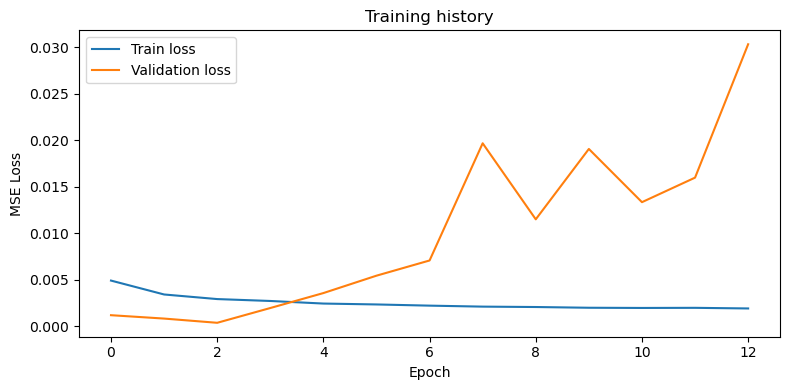

In [87]:
plt.figure(figsize=(8, 4))
plt.plot(history['train_loss'], label='Train loss')
plt.plot(history['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training history')
plt.legend()
plt.tight_layout()
plt.show()

## Evaluate the test set

In [88]:
# Evaluate the final model on the test set and compute performance metrics
test_loss, test_pred_scaled, test_obs_scaled = LSTM_helper.evaluate(model, criterion, device, test_loader)

# Inverse transform the scaled predictions and observations back to the original scale using the target scaler, and compute performance metrics (RMSE, MAE, R2) between the predicted and observed flow values on the test set
pred_flow = target_scaler.inverse_transform(test_pred_scaled.reshape(-1, 1)).ravel()
obs_flow = target_scaler.inverse_transform(test_obs_scaled.reshape(-1, 1)).ravel()

# Compute performance metrics between the predicted and observed flow values on the test set, including Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and R-squared (R2) score
rmse = math.sqrt(mean_squared_error(obs_flow, pred_flow))
mae = mean_absolute_error(obs_flow, pred_flow)
r2 = r2_score(obs_flow, pred_flow)

print('Test MSE (scaled):', test_loss)
print('Test RMSE:', rmse)
print('Test MAE:', mae)
print('Test R2:', r2)

Test MSE (scaled): 0.0008156566023302286
Test RMSE: 86.68156297261258
Test MAE: 70.11688995361328
Test R2: -38.423885345458984


## Plot observed vs predicted streamflow

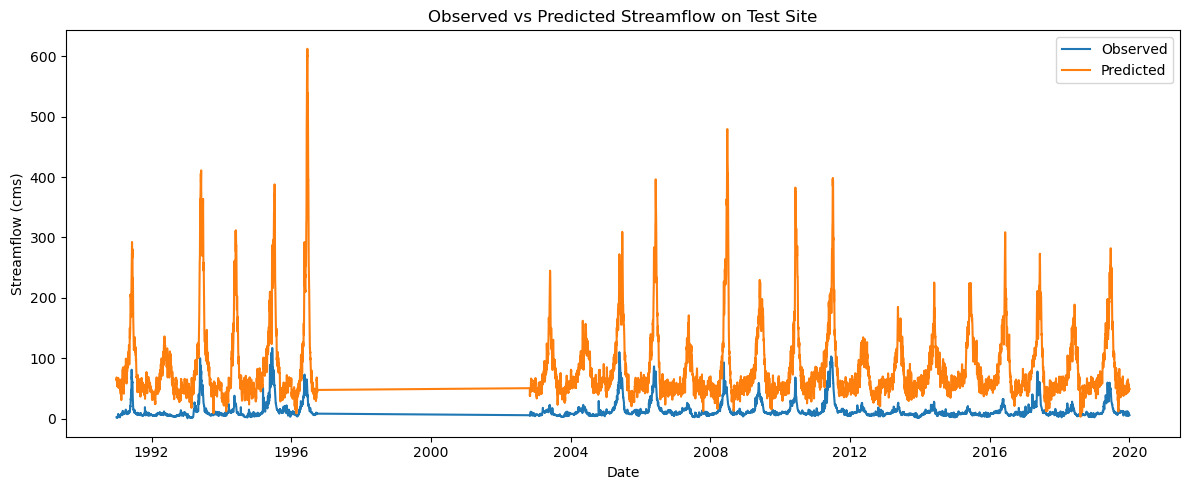

In [89]:
plt.figure(figsize=(12, 5))
plt.plot(d_test, obs_flow, label='Observed')
plt.plot(d_test, pred_flow, label='Predicted')
plt.xlabel('Date')
plt.ylabel('Streamflow (cms)')
plt.title('Observed vs Predicted Streamflow on Test Site')
plt.legend()
plt.tight_layout()
plt.show()

## Scatter plot of predicted versus observed values

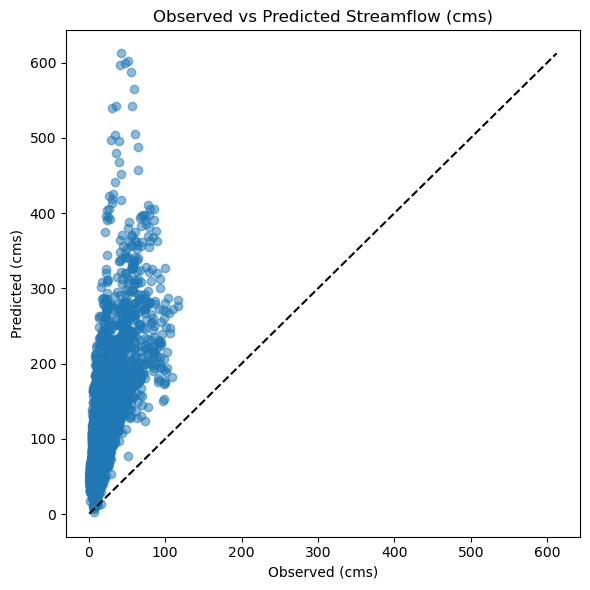

In [90]:
plt.figure(figsize=(6, 6))
plt.scatter(obs_flow, pred_flow, alpha=0.5)
lims = [min(obs_flow.min(), pred_flow.min()), max(obs_flow.max(), pred_flow.max())]
plt.plot(lims, lims, 'k--')
plt.xlabel('Observed (cms)')
plt.ylabel('Predicted (cms)')
plt.title('Observed vs Predicted Streamflow (cms)')
plt.tight_layout()
plt.show()

## Save the trained model

In [72]:
MODEL_PATH = 'model/LSTM/simple_lstm_streamflow.pt'

LSTM_helper.save_model(model, LOOKBACK_DAYS, feature_cols, feature_scaler, target_scaler, MODEL_PATH)

Saved model to: model/LSTM/simple_lstm_streamflow.pt
